# 03 — Final Evaluation of the Xception Baseline Model

In this notebook, the saved Xception baseline model is evaluated on the test dataset.

The model used in this stage is the best model saved during training using `ModelCheckpoint`, based on the lowest validation loss:
```text
models/xception_baseline_best.keras


# 1. Import Needed Libraries

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# 2. Path Configuration

In [18]:
PROJECT_ROOT = Path("..")
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
DATA_DIR = RESULTS_DIR / "dataframes"
TEST_DF_PATH = DATA_DIR / "test_dataframe.csv"

test_df = pd.read_csv(TEST_DF_PATH)

BEST_MODEL_PATH = MODELS_DIR / "xception_baseline.keras"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Main settings
BATCH_SIZE = 32
IMG_SIZE = (299, 299)

# 3. Data Loading and Training History

In [15]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False 
)

class_names = list(test_generator.class_indices.keys())
print(f"Classes: {class_names}")

Found 800 validated image filenames belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


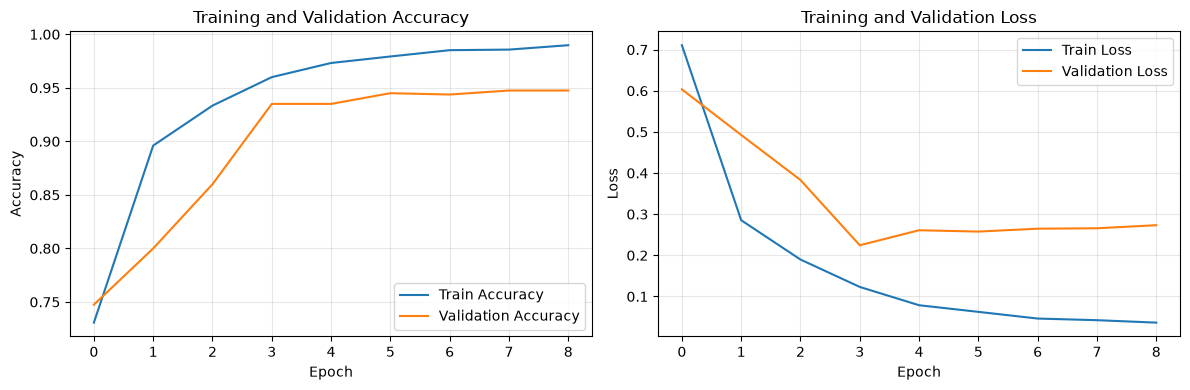

Training history plot saved to: ../results/figures/training_history.png


In [16]:
import pickle

HISTORY_PATH = RESULTS_DIR / "baseline_training_history.pkl"

with open(HISTORY_PATH, "rb") as file:
    history_data = pickle.load(file)

plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_data["accuracy"], label="Train Accuracy")
plt.plot(history_data["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_data["loss"], label="Train Loss")
plt.plot(history_data["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

HISTORY_FIGURE_PATH = FIGURES_DIR / "training_history.png"
plt.savefig(HISTORY_FIGURE_PATH, dpi=300, bbox_inches="tight")

plt.show()

print(f"Training history plot saved to: {HISTORY_FIGURE_PATH}")


In [ ]:
model = tf.keras.models.load_model(BEST_MODEL_PATH)
print("Model loaded successfully.")


# 4. Model Evaluation

In [20]:

y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n")
print(report)

# ذخیره گزارش در فایل متنی
with open(RESULTS_DIR / "classification_report.txt", "w") as f:
    f.write(report)


I0000 00:00:1787519513.448880   19174 cuda_dnn.cc:529] Loaded cuDNN version 90300


25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 271ms/step
Classification Report:

              precision    recall  f1-score   support

      glioma       0.93      0.86      0.90       200
  meningioma       0.90      0.90      0.90       200
     notumor       0.90      1.00      0.95       200
   pituitary       0.98      0.96      0.97       200

    accuracy                           0.93       800
   macro avg       0.93      0.93      0.93       800
weighted avg       0.93      0.93      0.93       800



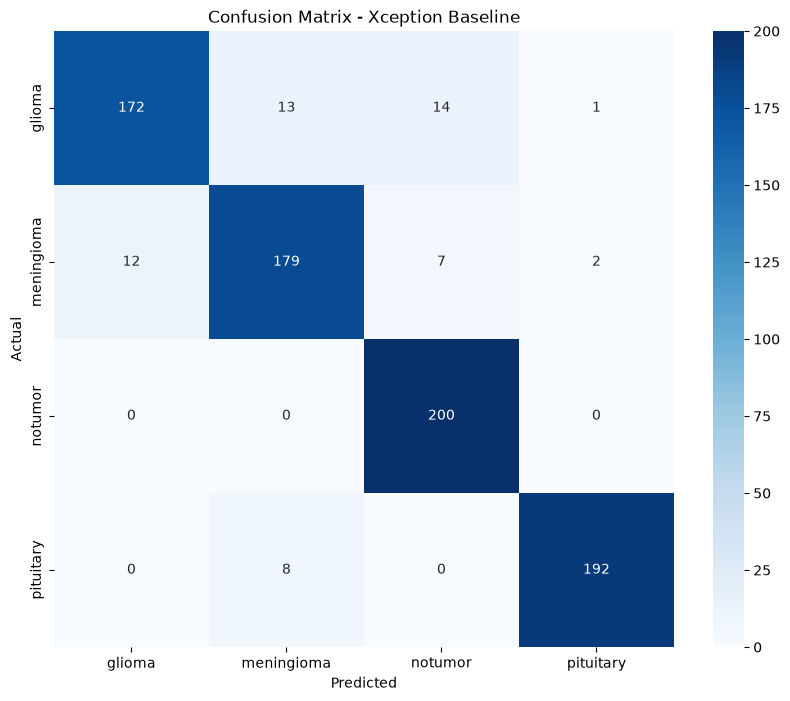

Figure saved to: ../results/figures/confusion_matrix.png


In [21]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Xception Baseline')
plt.ylabel('Actual')
plt.xlabel('Predicted')


plt.savefig(FIGURES_DIR / "confusion_matrix.png", dpi=300)
plt.show()

print(f"Figure saved to: {FIGURES_DIR / 'confusion_matrix.png'}")
